# Data Analysis - Linear Regression and Logistic Regression

This notebook demonstrates:
1. **Univariate and Multivariate Linear Regression** on California Housing dataset: [kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices)
2. **Logistic Regression** on Titanic dataset: [kaggle](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

In [47]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Linear Regression on California Housing Dataset

### Loading and Exploring the Housing Data

In [48]:
# Load the housing dataset
housing_df = pd.read_csv('data/housing.csv')

print(f"Housing: {housing_df.shape[0]} rows")
print(f"Target range: ${housing_df['median_house_value'].min():,.0f} - ${housing_df['median_house_value'].max():,.0f}")

Housing: 20640 rows
Target range: $14,999 - $500,001


In [49]:
# Handle missing values in total_bedrooms
housing_df['total_bedrooms'].fillna(housing_df['total_bedrooms'].median(), inplace=True)
print("Missing values handled")

Missing values handled


### 1.1 Univariate Linear Regression

Predicting median house value using median income as the single predictor.

In [50]:
# Univariate Linear Regression: median_income vs median_house_value
X_uni = housing_df[['median_income']]  # Feature (predictor)
y_uni = housing_df['median_house_value']  # Target variable

# Split the data into training and testing sets
X_uni_train, X_uni_test, y_uni_train, y_uni_test = train_test_split(
    X_uni, y_uni, test_size=0.2, random_state=42
)

# Create and train the linear regression model
uni_lr_model = LinearRegression()
uni_lr_model.fit(X_uni_train, y_uni_train)

# Make predictions
y_uni_pred = uni_lr_model.predict(X_uni_test)

# Calculate metrics
uni_mse = mean_squared_error(y_uni_test, y_uni_pred)
uni_r2 = r2_score(y_uni_test, y_uni_pred)

print("Univariate Linear Regression Results:")
print(f"R² Score: {uni_r2:.3f}")
print(f"RMSE: ${np.sqrt(uni_mse):,.0f}")

Univariate Linear Regression Results:
R² Score: 0.459
RMSE: $84,209


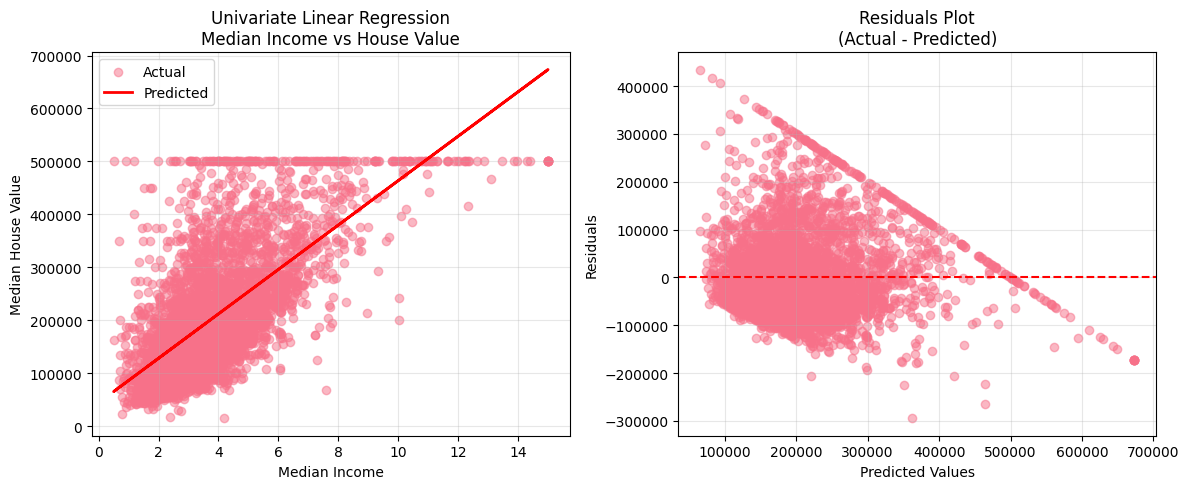

In [51]:
# Visualize the univariate linear regression
plt.figure(figsize=(12, 5))

# Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_uni_test, y_uni_test, alpha=0.5, label='Actual')
plt.plot(X_uni_test, y_uni_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Univariate Linear Regression\nMedian Income vs House Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Residuals plot
plt.subplot(1, 2, 2)
residuals = y_uni_test - y_uni_pred
plt.scatter(y_uni_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot\n(Actual - Predicted)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Multivariate Linear Regression

Predicting median house value using multiple features.

In [52]:
# Prepare data for multivariate regression
# We'll use numerical features and handle the categorical 'ocean_proximity'
housing_multi = housing_df.copy()

# One-hot encode the categorical variable
housing_encoded = pd.get_dummies(housing_multi, columns=['ocean_proximity'], prefix='ocean')

# Select features for multivariate regression (excluding target variable)
feature_columns = [col for col in housing_encoded.columns if col != 'median_house_value']
X_multi = housing_encoded[feature_columns]
y_multi = housing_encoded['median_house_value']

print(f"Features: {len(feature_columns)}")

# Split the data
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Scale the features for better performance
scaler = StandardScaler()
X_multi_train_scaled = scaler.fit_transform(X_multi_train)
X_multi_test_scaled = scaler.transform(X_multi_test)

Features: 13


In [53]:
# Create and train the multivariate linear regression model
multi_lr_model = LinearRegression()
multi_lr_model.fit(X_multi_train_scaled, y_multi_train)

# Make predictions
y_multi_pred = multi_lr_model.predict(X_multi_test_scaled)

# Calculate metrics
multi_mse = mean_squared_error(y_multi_test, y_multi_pred)
multi_r2 = r2_score(y_multi_test, y_multi_pred)

print("Multivariate Linear Regression Results:")
print(f"R² Score: {multi_r2:.3f}")
print(f"RMSE: ${np.sqrt(multi_mse):,.0f}")

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': multi_lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 3 Features:")
print(feature_importance.head(3)[['Feature']].to_string(index=False, header=False))

Multivariate Linear Regression Results:
R² Score: 0.625
RMSE: $70,061

Top 3 Features:
median_income
     latitude
    longitude


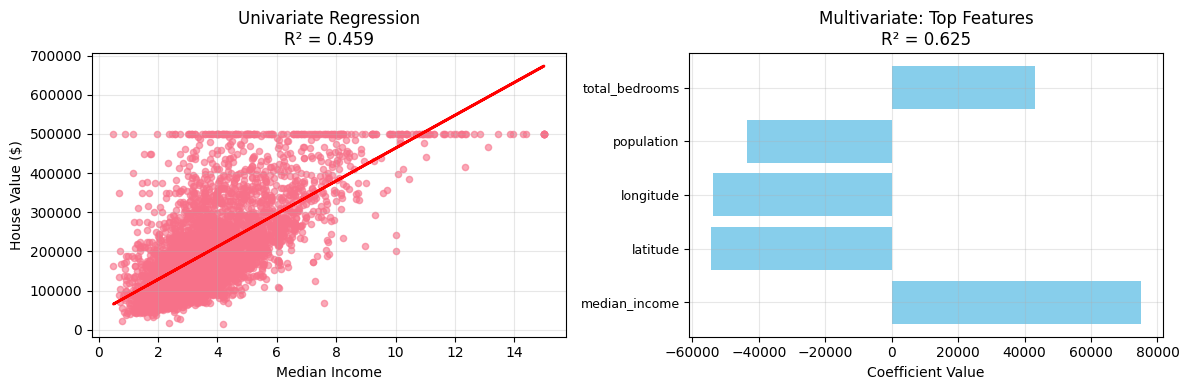


Model Comparison:
Univariate R²: 0.459
Multivariate R²: 0.625
Improvement: +36.3%


In [54]:
# Create a clean comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Univariate regression plot
axes[0].scatter(X_uni_test, y_uni_test, alpha=0.6, s=20)
axes[0].plot(X_uni_test, y_uni_pred, color='red', linewidth=2)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('House Value ($)')
axes[0].set_title(f'Univariate Regression\nR² = {uni_r2:.3f}')
axes[0].grid(True, alpha=0.3)

# Feature importance for multivariate
top_5_features = feature_importance.head(5)
axes[1].barh(range(len(top_5_features)), top_5_features['Coefficient'], color='skyblue')
axes[1].set_yticks(range(len(top_5_features)))
axes[1].set_yticklabels(top_5_features['Feature'], fontsize=9)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title(f'Multivariate: Top Features\nR² = {multi_r2:.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model comparison
print("\nModel Comparison:")
print(f"Univariate R²: {uni_r2:.3f}")
print(f"Multivariate R²: {multi_r2:.3f}")
print(f"Improvement: +{((multi_r2 - uni_r2) / uni_r2) * 100:.1f}%")

## 2. Logistic Regression on Titanic Dataset

### Loading and Exploring the Titanic Data

In [55]:
# Load the Titanic dataset
titanic_df = pd.read_csv('data/Titanic-Dataset.csv')

print(f"Titanic Dataset: {titanic_df.shape[0]} passengers")
print(f"Survival Rate: {titanic_df['Survived'].mean():.1%}")

Titanic Dataset: 891 passengers
Survival Rate: 38.4%


In [56]:
# Data preprocessing for Titanic dataset
titanic_processed = titanic_df.copy()

# Handle missing values
titanic_processed['Age'].fillna(titanic_processed['Age'].median(), inplace=True)
titanic_processed['Embarked'].fillna(titanic_processed['Embarked'].mode()[0], inplace=True)

# Drop irrelevant columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
titanic_processed = titanic_processed.drop(columns=columns_to_drop)

print("Preprocessing complete")

Preprocessing complete


In [57]:
# Encode categorical variables
titanic_processed['Sex'] = titanic_processed['Sex'].map({'male': 1, 'female': 0})
titanic_encoded = pd.get_dummies(titanic_processed, columns=['Embarked'], prefix='Embarked')

# Prepare features and target
X_titanic = titanic_encoded.drop('Survived', axis=1)
y_titanic = titanic_encoded['Survived']

print(f"Features: {X_titanic.shape[1]}")

# Split and scale the data
X_titanic_train, X_titanic_test, y_titanic_train, y_titanic_test = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)
titanic_scaler = StandardScaler()
X_titanic_train_scaled = titanic_scaler.fit_transform(X_titanic_train)
X_titanic_test_scaled = titanic_scaler.transform(X_titanic_test)

Features: 9


In [58]:
# Train logistic regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_titanic_train_scaled, y_titanic_train)
y_titanic_pred = logistic_model.predict(X_titanic_test_scaled)
y_titanic_pred_proba = logistic_model.predict_proba(X_titanic_test_scaled)[:, 1]

accuracy = accuracy_score(y_titanic_test, y_titanic_pred)
cm = confusion_matrix(y_titanic_test, y_titanic_pred)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy:.1%}")

# Feature importance
feature_names = X_titanic.columns
coefficients = logistic_model.coef_[0]
feature_importance_logistic = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 3 Features:")
print(feature_importance_logistic.head(3)[['Feature']].to_string(index=False, header=False))

Logistic Regression Results:
Accuracy: 80.4%

Top 3 Features:
   Sex
Pclass
   Age


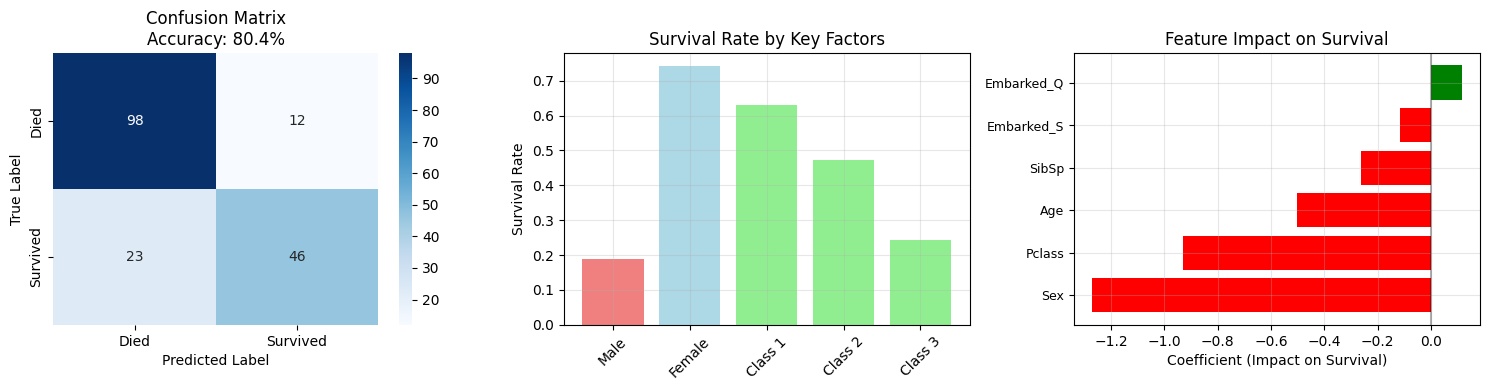

In [59]:
# Create clean visualizations for Titanic analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {accuracy:.1%}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Survival by key factors
survival_data = pd.DataFrame({
    'Factor': ['Male', 'Female', 'Class 1', 'Class 2', 'Class 3'],
    'Survival_Rate': [
        titanic_df[titanic_df['Sex'] == 'male']['Survived'].mean(),
        titanic_df[titanic_df['Sex'] == 'female']['Survived'].mean(),
        titanic_df[titanic_df['Pclass'] == 1]['Survived'].mean(),
        titanic_df[titanic_df['Pclass'] == 2]['Survived'].mean(),
        titanic_df[titanic_df['Pclass'] == 3]['Survived'].mean()
    ]
})

colors = ['lightcoral', 'lightblue', 'lightgreen', 'lightgreen', 'lightgreen']
axes[1].bar(survival_data['Factor'], survival_data['Survival_Rate'], color=colors)
axes[1].set_title('Survival Rate by Key Factors')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Feature importance
top_features = feature_importance_logistic.head(6)
axes[2].barh(range(len(top_features)), top_features['Coefficient'], 
            color=['red' if c < 0 else 'green' for c in top_features['Coefficient']])
axes[2].set_yticks(range(len(top_features)))
axes[2].set_yticklabels(top_features['Feature'], fontsize=9)
axes[2].set_xlabel('Coefficient (Impact on Survival)')
axes[2].set_title('Feature Impact on Survival')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Summary and Conclusions

### Results Summary

In [60]:
print("FINAL RESULTS")
print(f"\nLinear Regression:")
print(f"Univariate R²: {uni_r2:.3f}")
print(f"Multivariate R²: {multi_r2:.3f}")
print(f"\nLogistic Regression:")
print(f"Accuracy: {accuracy:.1%}")

FINAL RESULTS

Linear Regression:
Univariate R²: 0.459
Multivariate R²: 0.625

Logistic Regression:
Accuracy: 80.4%
